# Testing TorchDA with the Cahn-Hilliard Problem

The `forward_model` predicts the concentration based on $\kappa$. We want to vary $\kappa$ and try and see if we can predict the original value. We're solving

$$ \dot{\phi} = \nabla^2 \left( \phi^3 - \phi \right) - \gamma \nabla^4 \phi $$


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.fft import fft2, ifft2

In [84]:


def forward_model(nsteps=100, dt=0.1, N=256, dx=1.0, c0=0.5, kappa=1.0):

    c_hat = np.empty((N,N), dtype=np.complex64)
    dfdc_hat = np.empty((N,N), dtype=np.complex64)
    c = np.empty((nsteps,N,N), dtype=np.float32)
    L = N * dx
    noise = 0.1
    rng = np.random.default_rng(12345) # the seed of random numbers generator
    c[0] = c0 + 0.1 * rng.standard_normal(c[0].shape)

    kx = ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    K = np.array(np.meshgrid(kx , ky ,indexing ='ij'), dtype=np.float32)
    K2 = np.sum(K*K,axis=0, dtype=np.float32)

    # The anti-aliasing factor  
    kmax_dealias = kx.max() * 2.0 / 3.0 # The Nyquist mode
    dealias = np.array((np.abs(K[0]) < kmax_dealias) * (np.abs(K[1]) < kmax_dealias ),dtype =bool)

    def dfdc(c):
#        return c*3 - c
        return 2 * (c * (1 - c)**2 - (1 - c) * c**2)

    c_hat[:] = fft2(c[0])
    for i in range(1, nsteps):
        dfdc_hat[:] = fft2(dfdc(c[i-1])) # the FT of the derivative
        dfdc_hat *= dealias # dealising
        c_hat[:] = (c_hat - dt * K2 * dfdc_hat) / (1 + dt * kappa * K2**2) # updating in time
        c[i] = ifft2(c_hat).real # inverse fourier transform

    return c


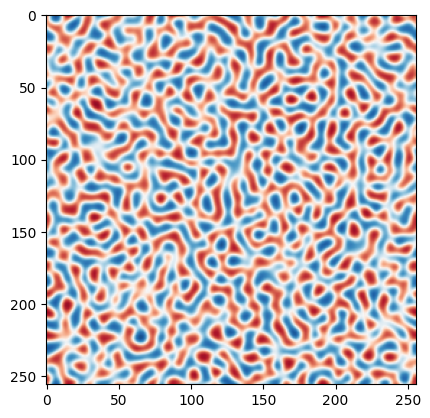

In [85]:

c = forward_model(nsteps=301, kappa=2.0)


plt.imshow(c[-1],cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.savefig('cahn-hilliard-c0-%.1f.png'% c0)
plt.show()

In [70]:
def H(nobs, x):
    rng = np.random.default_rng(1228075288403)
    i = rng.integers(0, high=x.shape[1], size=nobs, dtype=int)
    return x[:, i]
    

In [87]:
H(10, c[:5].reshape((5, c.shape[1] * c.shape[2])))

array([[0.532926  , 0.5479702 , 0.52886677, 0.47065455, 0.43981585,
        0.39618015, 0.42083034, 0.5175434 , 0.6749457 , 0.2788914 ],
       [0.48241466, 0.5160001 , 0.46468228, 0.48868954, 0.48240283,
        0.4374292 , 0.47696   , 0.5281329 , 0.538807  , 0.45469886],
       [0.48551264, 0.5217619 , 0.46046266, 0.4734177 , 0.4825256 ,
        0.4599173 , 0.47234988, 0.52452165, 0.51519156, 0.48113772],
       [0.49190965, 0.5263484 , 0.46028745, 0.46126178, 0.48259106,
        0.47137475, 0.468672  , 0.5202893 , 0.50480825, 0.4906827 ],
       [0.49679205, 0.5295845 , 0.46095076, 0.45363942, 0.48267338,
        0.47809252, 0.4670332 , 0.51678056, 0.49823424, 0.49543044]],
      dtype=float32)